# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [4]:
print(X.dtypes)
print(y.dtype)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object
int64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print("The target is categorical, so this is a classification task.")

The target is categorical, so this is a classification task.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("Data matrix (X):", X.shape)
print("Target (y):", y.shape)

Data matrix (X): (150, 4)
Target (y): (150,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
print("X summary:")
print(X.agg(["min", "max", "median", "mean", "std"]))

print("\nTarget class counts:")
print(y.value_counts().sort_index())

X summary:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
min              4.300000          2.000000           1.000000   
max              7.900000          4.400000           6.900000   
median           5.800000          3.000000           4.350000   
mean             5.843333          3.057333           3.758000   
std              0.828066          0.435866           1.765298   

        petal width (cm)  
min             0.100000  
max             2.500000  
median          1.300000  
mean            1.199333  
std             0.762238  

Target class counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

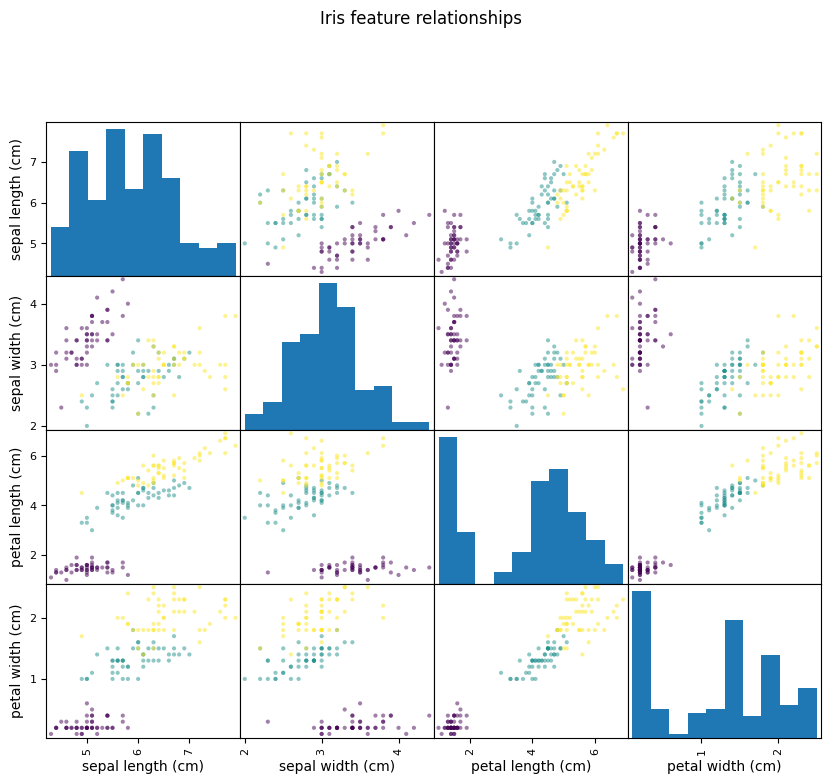

In [8]:
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(X, c=y, figsize=(10, 8), diagonal="hist")
plt.suptitle("Iris feature relationships", y=1.02)
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [9]:
X_sepal = X[["sepal length (cm)", "sepal width (cm)"]]
X_sepal.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [10]:
X_petal = X[["petal length (cm)", "petal width (cm)"]]
X_petal.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### Step 7. Initialize 2 `LogisticRegression` models

In [11]:
from sklearn.linear_model import LogisticRegression

model_sepal = LogisticRegression(max_iter=200)
model_petal = LogisticRegression(max_iter=200)

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [12]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    X.index, test_size=0.2, random_state=42, stratify=y
)

X_sepal_train = X_sepal.loc[train_idx]
X_sepal_test = X_sepal.loc[test_idx]
X_petal_train = X_petal.loc[train_idx]
X_petal_test = X_petal.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

### Step 9.a Train both models

In [13]:
model_sepal.fit(X_sepal_train, y_train)
model_petal.fit(X_petal_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [14]:
sepal_score = model_sepal.score(X_sepal_test, y_test)
petal_score = model_petal.score(X_petal_test, y_test)

print("Sepal model accuracy:", sepal_score)
print("Petal model accuracy:", petal_score)

Sepal model accuracy: 0.7333333333333333
Petal model accuracy: 0.9666666666666667


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [15]:
if petal_score > sepal_score:
    print("The petal features better distinguish the iris flowers, and the groups are easier to tell apart.")
else:
    print("The sepal features better distinguish the iris flowers.")

The petal features better distinguish the iris flowers, and the groups are easier to tell apart.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

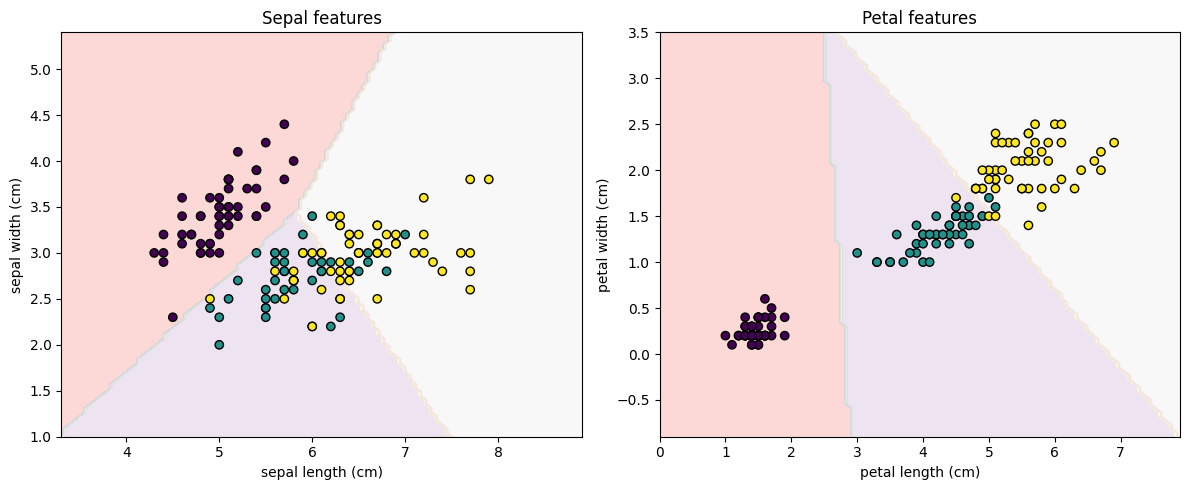

In [16]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

DecisionBoundaryDisplay.from_estimator(
    model_sepal, X_sepal, response_method="predict", cmap="Pastel1", alpha=0.5, ax=axes[0]
)
axes[0].scatter(X_sepal.iloc[:, 0], X_sepal.iloc[:, 1], c=y, edgecolor="k")
axes[0].set_title("Sepal features")

DecisionBoundaryDisplay.from_estimator(
    model_petal, X_petal, response_method="predict", cmap="Pastel1", alpha=0.5, ax=axes[1]
)
axes[1].scatter(X_petal.iloc[:, 0], X_petal.iloc[:, 1], c=y, edgecolor="k")
axes[1].set_title("Petal features")

plt.tight_layout()
plt.show()